## Setup

### Import Libraries

In [ ]:
import torch
import torch.nn as nn

from sklearn.datasets import make_moons, load_iris
import matplotlib.pyplot as plt

### Get Data

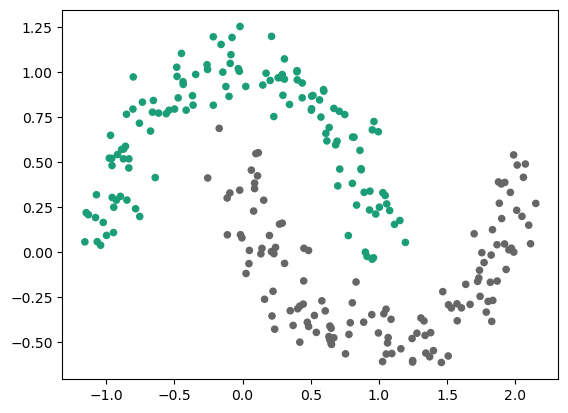

In [ ]:
X, y = make_moons(256, noise=0.1, random_state=42)
X= torch.from_numpy(X.astype('float32'))
#y = 2 * torch.from_numpy(y.astype('int32'))
y = torch.tensor(y, dtype=torch.long)


plt.scatter(*X.T, s = 20, c = y, cmap='Dark2');

In [ ]:
y

tensor(0.7008, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.4783, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.4376, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3982, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3751, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3588, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3463, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3362, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3279, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3209, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3150, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3100, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3056, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.3019, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.2986, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.2957, grad_fn=<BinaryCrossEntro

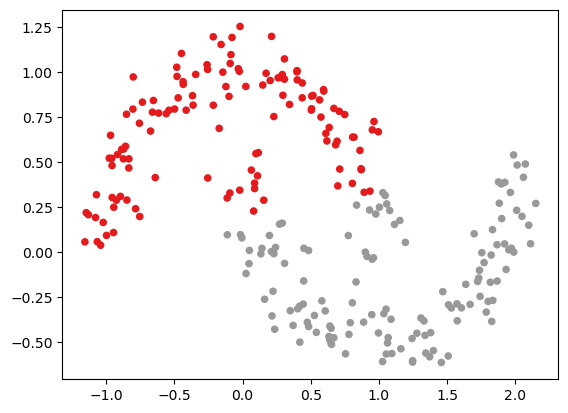

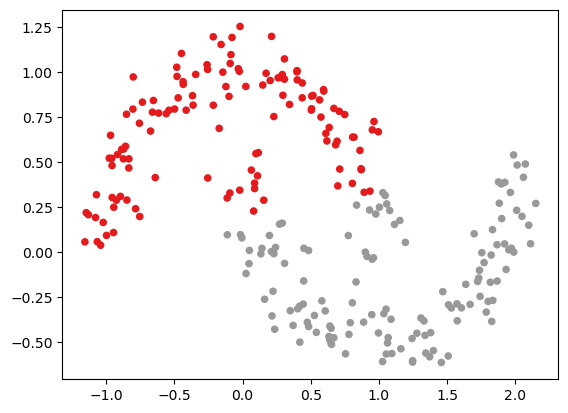

In [142]:
# Something is not working here, beyond the model not being good.  
# Try with more steps, you'll see

from torch import optim

torch.manual_seed(42)

model = nn.Linear(2, 1)  # linear regression

# model = nn.Sequential(
#     nn.Linear(2,16),
#     nn.ReLU(),
#     nn.Linear(16,2)
# )

optimizer = optim.RMSprop(model.parameters(), lr=0.1)  # Optimizer automatically updates parameters

for step in range(100):
    y_pred = model(X)  # forward pass (prediction)
    #loss = (y_pred - y).square().mean()  # error prediction (i.e. "loss")
    #loss = nn.CrossEntropyLoss()(y_pred, y)
    loss = nn.BCEWithLogitsLoss()(y_pred.squeeze(), y.float())
    print(loss)
    optimizer.zero_grad()  # 
    loss.backward()
    optimizer.step()


probs = torch.sigmoid(y_pred)
plt.figure()
plt.scatter(*X.T, s = 20, c = probs > 0.5, cmap='Set1');
plt.figure()
plt.scatter(*X.T, s = 20, c = y_pred > 0, cmap='Set1');
#plt.scatter(*X.T, s = 20, c = torch.argmax(y_pred, dim=1), cmap='Set1');


In [125]:
# Something is not working here, beyond the model not being good.  
# Try with more steps, you'll see

from torch import optim

torch.manual_seed(42)

model = nn.Linear(2, 1)  # linear regression

optimizer = optim.RMSprop(model.parameters(), lr=0.1)  # Optimizer automatically updates parameters

for step in range(1):
    y_pred = model(X)  # forward pass (prediction)
    loss = (y_pred - y).square().mean()  # error prediction (i.e. "loss")
    print(loss)
    optimizer.zero_grad()  # 
    loss.backward()
    optimizer.step()



plt.scatter(*X.T, s = 20, c = y_pred > 0, cmap='Set1');


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

## Section 2: Fit with a Neural Network Model

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | Creates a single layer of neurons that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.ReLU()` | Creates a rectified linear unit activation function.|
| `nn.Tanh()` | Creates a hyperbolic tangent activation function.|
| `nn.Softmax()` | Creates a softmax activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|

## Section 3: The Loss Function

| Code | Description |
| --- | --- |
| `net(X_input)` | Pass input `X_input` to a neuronal network `net`. |
| `y_net = net(X_input)` | Pass input `X_input` to a neuronal network `net` and assign the output to a variable `y_net`. |
| `loss_function = nn.MSELoss()` | Creates a mean squared error (MSE) loss function and assigns it to a variable named `loss_function`. Typically used for regression problems. |
| `nn.CrossEntropyLoss()` | Creates a cross-entropy loss function. Used for classification problems.|
| `nn.NLLLoss()` | Creates a negative log-likelihood loss function. Used for classification problems. Expects different input format than cross-entropy loss. |
| `loss_function = nn.CrossEntropyLoss()` | Creates a cross-entropy loss function and assigns it to a variable named `loss_function`. Typically used for regression problems. |
| `loss_function(y_net, y_true)` | Calculates the loss between the output of the network `y_net` and the true y-values from the data `y_true`. |
| `loss_function(y_net, y_true).item()` | Extracts the loss value (the number alone as a ``float`` and not as a ``tensor`` type). |

**Example**: Pass the input ``X_samples``  to the network `net` defined below. When you display the output from the network it should look something like this:

**TODO: Update numbers**

tensor([[-0.0750, -0.1321],  <br>
&nbsp;[-0.6765,  0.0395],  <br>
&nbsp;[-0.3084, -0.0583],  <br>
&nbsp;[-0.0244,  0.0879],  <br>
&nbsp;[-0.2079, -0.0272]], grad_fn=``<AddmmBackward0>``)

In [ ]:
# provided

# set seed for reproducibility
seed = 42
torch.manual_seed(seed)

# select subset of data
X_samples = X[:5]

# define network
net = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

In [ ]:
net(X_samples)

tensor([[ 0.2759,  0.3435],
        [ 0.1586,  0.0792],
        [-0.2391, -0.6694],
        [ 0.1299,  0.2777],
        [-0.3268, -0.8778]], grad_fn=<AddmmBackward0>)

**Exercise**: Create a network that is a sequence of two layers with a rectified linear unit between them and pass the input ``X_samples`` to the network. The net should have 2 input features and 10 output features in the first layer, 10 input features and 2 output features in the last layer, and a rectified linear unit between them.

**TODO: Update numbers**

When you display the output from the network it should look something like this:

tensor([[-0.7792,  0.3448], <br>
&nbsp;[-1.1195,  0.5286],  <br>
&nbsp;[-0.9589,  0.4255],  <br>
&nbsp;[-0.7205,  0.2652],  <br>
&nbsp;[-0.9274,  0.4547]], grad_fn=``<AddmmBackward0>``)

*Note*: If you get different numbers, it might be because you haven't set the seed before creating the network (see code provided in previous exercise).

In [ ]:
# set seed for reproducibility
seed = 42
torch.manual_seed(seed)

net = nn.Sequential(
    nn.Linear(2,10),
    nn.ReLU(),
    nn.Linear(10, 2)
)

net(X_samples)

tensor([[ 0.0641,  0.2361],
        [-0.0886,  0.0924],
        [-0.3893,  0.1175],
        [-0.1926,  0.1436],
        [-0.3431,  0.1260]], grad_fn=<AddmmBackward0>)

**Exercise**: Create a network that is a sequence of *three* layers with a *hyperbolic tangent activation function* between each layer and pass the input ``X_samples`` to the network. The net should have 2 input features in the first layer, and 32 output features in the first layer, 32 input features and 32 output features in the second layer, and 32 input features and 2 output features in last layer.

In [ ]:
net = nn.Sequential(
    nn.Linear(2,32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32,2)
)

net(X_samples)

tensor([[-0.2211,  0.1321],
        [-0.2285,  0.0786],
        [-0.1711, -0.1686],
        [-0.1933,  0.1706],
        [-0.0594, -0.1528]], grad_fn=<AddmmBackward0>)

**Example**: Create a negative log-likelihood loss function.

In [263]:
loss_function = nn.NLLLoss()
loss_function

NLLLoss()

**Exercise**: Create a mean square error loss function.

In [264]:
loss_function = nn.MSELoss()
loss_function

MSELoss()

**Exercise**: Create a cross entropy loss function.

In [265]:
loss_function = nn.CrossEntropyLoss()
loss_function

CrossEntropyLoss()

**Exercise**: Calculate the loss between the output `y_net` produced by the neural net in the cell below and the original y-data `y_true`.

In [ ]:
# provided

# create net
net = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

# select subset of data
X_samples = X[:5]
y_true = y[:5]

# pass subset to network
y_net = net(X_samples)

# define loss function
loss_function = nn.CrossEntropyLoss()

In [267]:
loss_function(y_net, y_true)

tensor(0.7451, grad_fn=<NllLossBackward0>)

**Exercise**: Extract the value of the loss (the number alone).

**Hint**: ``.item()``

In [268]:
loss_function(y_net, y_true).item()

0.7450814247131348

**Exercise**: Assign the loss value to a variable named `loss`.

In [269]:
loss = loss_function(y_net, y_true).item()
loss

0.7450814247131348

## Sectoin 4: The Optimizer

| Code | Description |
| --- | --- |
| `optim.SGD(net.parameters())` | Creates a stochastic gradient descent (GD) optimizer. |
| `optim.SGD(net.parameters(), lr=0.01, momentum = 0.99)` | Creates a stochastic gradient descent (GD) optimizer with a learning rate `lr` of 0.01 (the default value is 0.001) and ``momentum`` of 0.99 (the default value is 0.9). |
| `optim.Adagrad(net.parameters())` | Creates an adaptive gradient descent optimizer.|
| `optim.ADAM(net.parameters())` | Creates an adaptive moment optimizer .|
| `optimizer = optim.SGD(net.parameters())` | Creates a stochastic gradient descent (GD) optimizer and assigns it to a variable called `optimizer`. |

**Example**: Create a stochastic gradient descent optimizer for the parameters of the network `net`.

In [ ]:
optimizer = torch.optim.SGD(net.parameters())
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

**Exercise**: Create an adaptive gradient (Adagrad) optimize.

In [ ]:
optimizer = torch.optim.Adagrad(net.parameters())
optimizer

Adagrad (
Parameter Group 0
    differentiable: False
    eps: 1e-10
    foreach: None
    fused: None
    initial_accumulator_value: 0
    lr: 0.01
    lr_decay: 0
    maximize: False
    weight_decay: 0
)

**Exercise**: Create an adaptive moment (Adam) optimizer with learning rate ``lr = 0.01``.

In [ ]:
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

**Exercise**: Create a gradient descent optimizer with `momentum = 0.95` and learning rate `lr = 0.01`.

In [ ]:
optimizer = torch.optim.SGD(net.parameters(), lr = 0.01, momentum = 0.95)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.95
    nesterov: False
    weight_decay: 0
)